In [1]:
# gw-gain-main.ipynb

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import anndata as ad
import logging
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import sys

In [4]:
in_dir = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/rs_benchmark/baf/gene/base/gw-gain/pp"
out_stat_dir = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/rs_benchmark/baf/gene/base/gw-gain/stats"
out_fig_dir = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/rs_benchmark/baf/gene/base/gw-gain/figures"

In [5]:
utils_dir = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/rs_benchmark/baf/gene/base/scripts"
sys.path.append(utils_dir)
from ubase import *
from ubaf import *
from urdr import stat_stack_zeroprop, stat_LR

In [6]:
os.makedirs(out_stat_dir, exist_ok = True)
os.makedirs(out_fig_dir, exist_ok = True)

In [7]:
cw_prefix = 'cw-'
gw_prefix = 'gw-'

dpi = 300

In [8]:
blue = '#0072B2'
orange = '#E69F00'
green = '#009E73'
red = '#D55E00'     # Vermillion

def_color = blue

In [9]:
tool_labels = ['seed_N', 'stCNASim-rs_N', 'scReadSim-cna_N', 'stCNASim-rs_T', 'scReadSim-cna_T']
tool_palette = {
    'seed_N': orange,
    'stCNASim-rs_N': '#56B4E9',
    'scReadSim-cna_N': green,
    'stCNASim-rs_T': '#F0E442',
    'scReadSim-cna_T': blue
}

# Load Data

In [10]:
seed_normal_fn = os.path.join(in_dir, "seed_normal.h5ad")
rs_normal_fn = os.path.join(in_dir, "rs_normal.h5ad")
rs_tumor_fn = os.path.join(in_dir, "rs_tumor.h5ad")
scrs_normal_fn = os.path.join(in_dir, "scrs_normal.h5ad")
scrs_tumor_fn = os.path.join(in_dir, "scrs_tumor.h5ad")

In [11]:
seed_normal = ad.read_h5ad(seed_normal_fn)
print(seed_normal)

rs_normal = ad.read_h5ad(rs_normal_fn)
print(rs_normal)

rs_tumor = ad.read_h5ad(rs_tumor_fn)
print(rs_tumor)

scrs_normal = ad.read_h5ad(scrs_normal_fn)
print(scrs_normal)

scrs_tumor = ad.read_h5ad(scrs_tumor_fn)
print(scrs_tumor)

AnnData object with n_obs × n_vars = 600 × 2303
    obs: 'cell', 'cell_type'
    var: 'chrom', 'start', 'end', 'feature', 'strand'
    layers: 'A', 'B', 'U'
AnnData object with n_obs × n_vars = 600 × 2303
    obs: 'cell', 'cell_type'
    var: 'chrom', 'start', 'end', 'feature', 'strand'
    layers: 'A', 'B', 'U'
AnnData object with n_obs × n_vars = 600 × 2303
    obs: 'cell', 'cell_type'
    var: 'chrom', 'start', 'end', 'feature', 'strand'
    layers: 'A', 'B', 'U'
AnnData object with n_obs × n_vars = 600 × 2303
    obs: 'cell', 'cell_type'
    var: 'chrom', 'start', 'end', 'feature', 'strand'
    layers: 'A', 'B', 'U'
AnnData object with n_obs × n_vars = 600 × 2303
    obs: 'cell', 'cell_type'
    var: 'chrom', 'start', 'end', 'feature', 'strand'
    layers: 'A', 'B', 'U'


# Gene-wise Metrics

In [12]:
mv = get_gw_metrics_group(
    adata_lst = [seed_normal, rs_normal, scrs_normal, rs_tumor, scrs_tumor],
    X_names = tool_labels,
    id_lst = [seed_normal.var['feature'].to_numpy(), rs_normal.var['feature'].to_numpy(), scrs_normal.var['feature'].to_numpy(),
             rs_tumor.var['feature'].to_numpy(), scrs_tumor.var['feature'].to_numpy()],
    metrics = ["mean", "var", "cv", "zero_prop", "sum"]
)
mv = mv.rename(columns = dict(X_name = 'group'))
mv

,mean_A,var_A,cv_A,zero_prop_A,sum_A,X_name_A,feature_A,mean_B,var_B,cv_B,...,var_ABU,cv_ABU,zero_prop_ABU,sum_ABU,X_name_ABU,feature_ABU,group,feature,DP,baf
0,0.0,0.0,0.0,1.0,0,seed_N,AC239859.3,0.0,0.0,0.0,...,0.000000,0.000000,1.000000,0,seed_N,AC239859.3,seed_N,AC239859.3,0,NaN
1,0.0,0.0,0.0,1.0,0,seed_N,AC239800.2,0.0,0.0,0.0,...,0.122267,2.913888,0.886667,72,seed_N,AC239800.2,seed_N,AC239800.2,0,NaN
2,0.0,0.0,0.0,1.0,0,seed_N,AC239800.3,0.0,0.0,0.0,...,0.019600,7.000000,0.980000,12,seed_N,AC239800.3,seed_N,AC239800.3,0,NaN
3,0.0,0.0,0.0,1.0,0,seed_N,AC239798.2,0.0,0.0,0.0,...,0.000000,0.000000,1.000000,0,seed_N,AC239798.2,seed_N,AC239798.2,0,NaN
4,0.0,0.0,0.0,1.0,0,seed_N,AC246680.1,0.0,0.0,0.0,...,0.000000,0.000000,1.000000,0,seed_N,AC246680.1,seed_N,AC246680.1,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11510,0.0,0.0,0.0,1.0,0,scReadSim-cna_T,ZNF250,0.0,0.0,0.0,...,0.016389,7.681146,0.983333,10,scReadSim-cna_T,ZNF250,scReadSim-cna_T,ZNF250,0,NaN
11511,0.0,0.0,0.0,1.0,0,scReadSim-cna_T,ZNF16,0.0,0.0,0.0,...,0.085100,4.167415,0.940000,42,scReadSim-cna_T,ZNF16,scReadSim-cna_T,ZNF16,0,NaN
11512,0.0,0.0,0.0,1.0,0,scReadSim-cna_T,AF235103.1,0.0,0.0,0.0,...,0.000000,0.000000,1.000000,0,scReadSim-cna_T,AF235103.1,scReadSim-cna_T,AF235103.1,0,NaN
11513,0.0,0.0,0.0,1.0,0,scReadSim-cna_T,ZNF252P-AS1,0.0,0.0,0.0,...,0.000000,0.000000,1.000000,0,scReadSim-cna_T,ZNF252P-AS1,scReadSim-cna_T,ZNF252P-AS1,0,NaN


In [13]:
tmp = mv.copy()

tmp.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "metric_values.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

In [14]:
np.log10(mv['mean_ABU'].min() + 1), np.log10(mv['mean_ABU'].max() + 1)

(0.0, 2.2356883321079355)

In [15]:
np.log10(mv['mean_AB'].min() + 1), np.log10(mv['mean_AB'].max() + 1)

(0.0, 1.0612010785117776)

In [16]:
np.log10(mv['DP'].min() + 1), np.log10(mv['DP'].max() + 1)

(0.0, 3.799960527405984)

## Single Metric

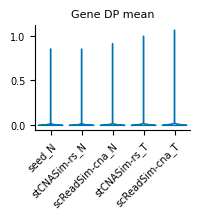

In [17]:
fig = plt.figure(figsize = (2.1, 2.3))

x = mv['group']
y = mv['mean_AB']
y = np.log10(y + 1)
ax = sns.violinplot(
    x = x, y = y, 
    fill = False, 
    palette = [def_color] * len(tool_labels), 
    hue = x, 
    legend = False,
    inner = None,
    cut = 0,
    linewidth = 1.0
)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(
    ax.get_xticklabels(), 
    rotation = 45, rotation_mode = "anchor",
    ha = 'right', fontsize = 7
)
ax.set_yticks([0, 0.5, 1])
ax.set_yticklabels(
    ax.get_yticklabels(), 
    fontsize = 7
)
ax.set_xlabel(None)
ax.set_ylabel(None)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.title(r"Gene DP mean", fontsize = 8)

plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "DP-mean.png")
fig.savefig(fn, dpi = 300)

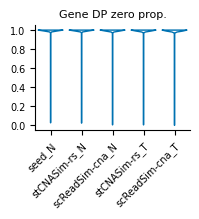

In [18]:
fig = plt.figure(figsize = (2.1, 2.3))

x = mv['group']
y = mv['zero_prop_AB']
ax = sns.violinplot(
    x = x, y = y, 
    fill = False, 
    palette = [def_color] * len(tool_labels), 
    hue = x, 
    legend = False,
    inner = None,
    cut = 0,
    linewidth = 1.0
)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(
    ax.get_xticklabels(), 
    rotation = 45, rotation_mode = "anchor",
    ha = 'right', fontsize = 7
)
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(
    ax.get_yticklabels(), 
    fontsize = 7
)
ax.set_xlabel(None)
ax.set_ylabel(None)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.title(r"Gene DP zero prop.", fontsize = 8)

plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "DP-zero_prop.png")
fig.savefig(fn, dpi = 300)

### Percentage of genes within specific ranges of zero proportions

In [19]:
st_zeroprop = stat_stack_zeroprop(
    data = mv, 
    metric = "zero_prop_AB",
    group = "group", 
    cutoffs = [.9, .99, 1.01], 
    labels = ["[0, 0.9)", "[0.9, 0.99)", "[0.99, 1]"]
)
print(st_zeroprop)


tmp = st_zeroprop[["group", "cutoff", "label", "percent"]]
tmp.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "DP-perc-of-genes-on-zero_prop.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

              group  level_1  cutoff        label    percent
0            seed_N        0    0.90     [0, 0.9)   0.955276
1            seed_N        1    0.99  [0.9, 0.99)   2.865827
2            seed_N        2    1.01    [0.99, 1]  96.178897
3     stCNASim-rs_N        0    0.90     [0, 0.9)   0.955276
4     stCNASim-rs_N        1    0.99  [0.9, 0.99)   2.865827
5     stCNASim-rs_N        2    1.01    [0.99, 1]  96.178897
6   scReadSim-cna_N        0    0.90     [0, 0.9)   1.128962
7   scReadSim-cna_N        1    0.99  [0.9, 0.99)   3.126357
8   scReadSim-cna_N        2    1.01    [0.99, 1]  95.744681
9     stCNASim-rs_T        0    0.90     [0, 0.9)   1.259227
10    stCNASim-rs_T        1    0.99  [0.9, 0.99)   3.082935
11    stCNASim-rs_T        2    1.01    [0.99, 1]  95.657838
12  scReadSim-cna_T        0    0.90     [0, 0.9)   1.606600
13  scReadSim-cna_T        1    0.99  [0.9, 0.99)   3.082935
14  scReadSim-cna_T        2    1.01    [0.99, 1]  95.310465


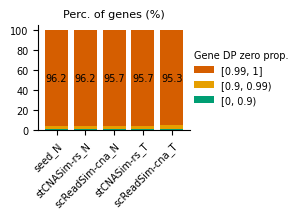

In [20]:
data = st_zeroprop
x, y, hue = 'group', 'percent', 'label'
min_v = 5
font_size = 7
colors = [green, orange, red]

# prepare data.
df = long2wide(data, index = x, columns = hue, values = y)
df[x] = df.index
hue_groups = data[hue].unique()
cumsum = np.array([0.0] * df.shape[0])

# plot.
fig = plt.figure(figsize = (3.1, 2.3))

for i, h in enumerate(hue_groups):
    if i == 0:
        plt.bar(df[x], df[h], label = h, color = colors[i])
    else:
        ax = plt.gca()
        ax.bar(df[x], df[h], label = h, bottom = cumsum, color = colors[i])
    cumsum += df[h]
        
for c in ax.containers:
    labels = [str(round(v.get_height(), 1))    \
                if v.get_height() > min_v else '' for v in c]
    ax.bar_label(c, label_type = 'center', labels = labels, 
                    fontsize = font_size, color = 'black')

ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(
    ax.get_xticklabels(), 
    rotation = 45, rotation_mode = "anchor",
    ha = 'right', fontsize = 7
)
ax.set_yticks([0, 20, 40, 60, 80, 100])
ax.set_yticklabels(
    ax.get_yticklabels(), 
    fontsize = 7
)
ax.set_ylabel("")
ax.set_xlabel("")

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles = handles[::-1],
    labels = labels[::-1],
    title = "Gene DP zero prop.",
    loc = 'center left',
    bbox_to_anchor = [0.97, 0.5],
    title_fontsize = font_size,
    fontsize = font_size,
    alignment = 'left',
    frameon = False
)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.title(r"Perc. of genes (%)", fontsize = 8)

plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "DP-perc-of-genes-on-zero_prop.png")
fig.savefig(fn, dpi = 300)

### BAF

In [21]:
mv_ind, idx_ind = remove_nan_baf(mv, how = 'independent')
print(mv_ind)

         mean_A     var_A       cv_A  zero_prop_A  sum_A         X_name_A  \
53     0.086667  0.085822   3.380242     0.916667     52           seed_N   
106    0.005000  0.004975  14.106736     0.995000      3           seed_N   
114    0.006667  0.006622  12.206555     0.993333      4           seed_N   
115    0.010000  0.009900   9.949874     0.990000      6           seed_N   
119    0.003333  0.003322  17.291616     0.996667      2           seed_N   
...         ...       ...        ...          ...    ...              ...   
11486  0.000000  0.000000   0.000000     1.000000      0  scReadSim-cna_T   
11488  0.000000  0.000000   0.000000     1.000000      0  scReadSim-cna_T   
11497  0.000000  0.000000   0.000000     1.000000      0  scReadSim-cna_T   
11498  0.000000  0.000000   0.000000     1.000000      0  scReadSim-cna_T   
11508  0.000000  0.000000   0.000000     1.000000      0  scReadSim-cna_T   

      feature_A    mean_B     var_B       cv_B  ...   var_ABU    cv_ABU  \


In [22]:
tmp = mv_ind.copy()
tmp.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "metric_values-filter_nan_independent.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

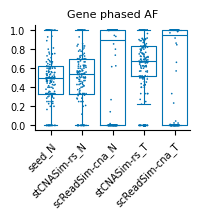

In [23]:
fig = plt.figure(figsize = (2.1, 2.3))

x = mv_ind['group']
y = mv_ind['baf']
ax = sns.boxplot(
    x = x, y = y, 
    fill = False, 
    palette = [def_color] * len(tool_labels), 
    hue = x, 
    legend = False,
    showfliers = True,
    fliersize = 0.8,
    linewidth = 0.8
)
sns.stripplot(
    x = x, y = y, 
    palette = [def_color] * len(tool_labels), 
    hue = x, 
    legend = False, 
    ax = ax,
    size = 1.2, 
    jitter = 0.15
)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(
    ax.get_xticklabels(), 
    rotation = 45, rotation_mode = "anchor",
    ha = 'right', fontsize = 7
)
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(
    ax.get_yticklabels(), 
    fontsize = 7
)
ax.set_xlabel(None)
ax.set_ylabel(None)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.title(r"Gene phased AF", fontsize = 8)

plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "baf.png")
fig.savefig(fn, dpi = 300)

## Linear Regression

In [24]:
pairs = [
    ("stCNASim-rs_N", "seed_N"),
    ("scReadSim-cna_N", "seed_N"),
    ("stCNASim-rs_N", "scReadSim-cna_N"),
    ("stCNASim-rs_T", "scReadSim-cna_T")
]

selected_gvars = pd.DataFrame(data = dict(
    x = [p[1] for p in pairs],
    y = [p[0] for p in pairs],
))

In [25]:
mv_isec, idx_isec = remove_nan_baf(mv, how = 'intersect')
print(mv_isec)


tmp = mv_isec.copy()
tmp.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "metric_values-filter_nan_intersect.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

         mean_A     var_A       cv_A  zero_prop_A  sum_A         X_name_A  \
53     0.086667  0.085822   3.380242     0.916667     52           seed_N   
106    0.005000  0.004975  14.106736     0.995000      3           seed_N   
114    0.006667  0.006622  12.206555     0.993333      4           seed_N   
115    0.010000  0.009900   9.949874     0.990000      6           seed_N   
119    0.003333  0.003322  17.291616     0.996667      2           seed_N   
...         ...       ...        ...          ...    ...              ...   
11441  0.081667  0.081664   3.499212     0.921667     49  scReadSim-cna_T   
11486  0.000000  0.000000   0.000000     1.000000      0  scReadSim-cna_T   
11488  0.000000  0.000000   0.000000     1.000000      0  scReadSim-cna_T   
11497  0.000000  0.000000   0.000000     1.000000      0  scReadSim-cna_T   
11498  0.000000  0.000000   0.000000     1.000000      0  scReadSim-cna_T   

      feature_A    mean_B     var_B       cv_B  ...   var_ABU    cv_ABU  \


In [26]:
st_lr = stat_LR(
    data = mv_isec,
    metric = "baf", group = "group", gvars = selected_gvars, 
    log_scale = True
)
print(st_lr)

tmp = st_lr.copy()
tmp.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "baf-lr-stat.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

                 x                y         a         b        r2  \
0           seed_N    stCNASim-rs_N  0.985230  0.008367  0.693435   
1           seed_N  scReadSim-cna_N  0.340941  0.098175  0.022627   
2  scReadSim-cna_N    stCNASim-rs_N  0.062897  0.168160  0.014518   
3  scReadSim-cna_T    stCNASim-rs_T  0.030259  0.209454  0.004194   

        p_value  
0  1.796060e-36  
1  7.933878e-02  
2  1.607647e-01  
3  4.521277e-01  


In [27]:
df_baf = long2wide(mv_isec, columns = 'group', values = 'baf', index = 'feature')
print(df_baf)

tmp = df_baf.copy()
tmp.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "baf-lr.tsv"), 
    header = True, 
    index = True, 
    sep = "\t"
)

group       seed_N  stCNASim-rs_N  scReadSim-cna_N  stCNASim-rs_T  \
feature                                                             
CHD1L     0.474747       0.441176         0.000000       0.615385   
ANP32E    0.500000       0.625000         0.000000       0.769231   
RPRD2     0.555556       0.555556         0.933333       0.687500   
TARS2     0.812500       0.812500         1.000000       0.909091   
ADAMTSL4  0.333333       0.333333         1.000000       0.400000   
...            ...            ...              ...            ...   
PYCR3     0.250000       0.333333         0.000000       0.486486   
TONSL     0.600000       0.727273         1.000000       0.916667   
CYHR1     0.729730       0.756098         1.000000       0.868852   
LRRC14    0.680000       0.733333         1.000000       0.814815   
LRRC24    0.461538       0.416667         1.000000       0.666667   

group     scReadSim-cna_T  
feature                    
CHD1L            0.000000  
ANP32E           0

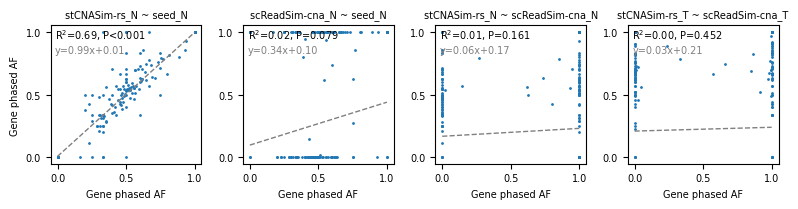

In [28]:
ncols = 4
fig, axs = plt.subplots(nrows = 1, ncols = ncols, figsize = (8.0, 2.2))

pos_r = (.03, .9)
pos_fit = (.03, .8)
fit_kws = dict()
fontsize = 7

columns = np.asarray(df_baf.columns)
df = df_baf[columns].copy()

gvars = st_lr[['x', 'y']].copy()
k = 0
for i in range(gvars.shape[0]):
    ax = axs.flat[k]
    cx = gvars['x'].loc[i]
    cy = gvars['y'].loc[i]
    d = st_lr.loc[(st_lr['x'] == cx) & (st_lr['y'] == cy)]
    assert d.shape[0] == 1
    a = d['a'].iloc[0]
    b = d['b'].iloc[0]
    r2 = d['r2'].iloc[0]
    p_value = d['p_value'].iloc[0]

    x, y = df[cx], df[cy]
    ax.plot(x, y, marker = '.', markersize = 2, linestyle = 'none')
    x_vals = np.linspace(max(ax.get_xlim()[0], np.min(x)), 
                        min(ax.get_xlim()[1], np.max(x)), 100)

    color_fit = fit_kws.get('color', 'gray')
    ax.plot(
        x_vals, a*x_vals+b, 
        linestyle = fit_kws.get('linestyle', '--'), 
        color = color_fit, 
        linewidth = fit_kws.get('linewidth', 1.0)
    )
    equation_str = format_equation(a, b)
    ax.annotate(equation_str, xy = pos_fit, xycoords = ax.transAxes,
                color = color_fit, fontsize = fontsize)
    pv_str = format_pvalue(p_value) 
    ax.annotate(r"R$^2$=%.2f, %s" % (r2, pv_str), xy = pos_r, 
                xycoords = ax.transAxes, fontsize = fontsize)

    ax.set_title(None)
    ax.set_xlabel("Gene phased AF", fontsize = fontsize)
    if k % ncols == 0:
        ax.set_ylabel("Gene phased AF", fontsize = fontsize)
    ax.set_title(cy + ' ~ ' + cx, fontsize = fontsize)
    ax.set_xticks([0, 0.5, 1])
    ax.set_xticklabels(
        ax.get_xticklabels(), 
        fontsize = fontsize
    )
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels(
        ax.get_yticklabels(), 
        fontsize = fontsize
    )
    k += 1

for ax in axs:
    for s in ["top", "right"]:
        ax.spines[s].set_visible(True)
        
plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "baf-lr.png")
fig.savefig(fn, dpi = 300)

### BAF vs. Mean

In [29]:
selected_gvars = ['seed_N', 'stCNASim-rs_N', 'scReadSim-cna_N', 'stCNASim-rs_T', 'scReadSim-cna_T']

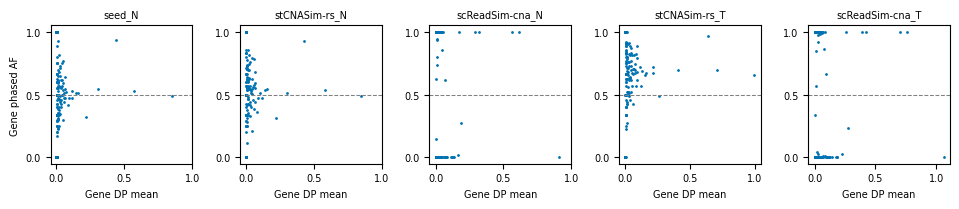

In [30]:
ncols = 5
fig, axs = plt.subplots(nrows = 1, ncols = ncols, figsize = (9.7, 2.2))

fontsize = 7

gvars = selected_gvars
k = 0
for i in range(len(gvars)):
    ax = axs[k]
    cx = gvars[i]
    df = mv_ind.loc[mv_ind['group'] == cx].copy()

    vx = df['mean_AB'].to_numpy()
    vy = df['baf'].to_numpy()
    vx = np.log10(vx + 1)
    
    ax.plot(vx, vy, marker = '.', markersize = 2, 
            linestyle = 'none', color = def_color)

    ref_kws = dict()
    ax.axhline(
        y = ref_kws.get('y', 0.5), 
        linestyle = ref_kws.get('linestyle', '--'), 
        linewidth = ref_kws.get('linewidth', 0.75),
        color = ref_kws.get('color', 'gray')
    )
    ax.set_xticks([0, 0.5, 1])
    ax.set_xticklabels(
        ax.get_xticklabels(), 
        fontsize = fontsize
    )
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels(
        ax.get_yticklabels(), 
        fontsize = fontsize
    )
    ax.set_xlabel("Gene DP mean", fontsize = fontsize)
    if k % ncols == 0:
        ax.set_ylabel("Gene phased AF", fontsize = fontsize)
    ax.set_title(cx, fontsize = fontsize)
    k += 1

for ax in axs:
    for s in ["top", "right"]:
        ax.spines[s].set_visible(True)
        
plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "baf-vs-DP-mean.png")
fig.savefig(fn, dpi = 300)